# Imports

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch

In [ ]:
import datasets
import matplotlib.pyplot as plt
import numpy as np
import sklearn.metrics
import sklearn.model_selection
import tqdm.notebook as tqdm
import transformers

c:\Users\Yanovich\Documents\Projects\Cats\neural\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print('CUDA:', torch.version.cuda)
print('GPU:', torch.cuda.is_available())

CUDA: 12.8
GPU: True


# Dataset

Load the dataset (we will be using [go_emotions](https://huggingface.co/datasets/google-research-datasets/go_emotions)). Pretokenize data or make a loader that tokenizes the sentenses as you iterate through the dataset. Implement two datasets: variable and fixed sentence length (in tokens). Don't forget to split the dataset into train and test subsets

In [4]:
dataset = datasets.load_dataset('google-research-datasets/go_emotions', name='raw', split='train')

In [5]:
emotions = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity',
    'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

In [6]:
tokenizer = transformers.AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

In [7]:
dataset

Dataset({
    features: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
    num_rows: 211225
})

In [8]:
df = dataset.to_pandas()

In [9]:
import seaborn as sns

<Axes: >

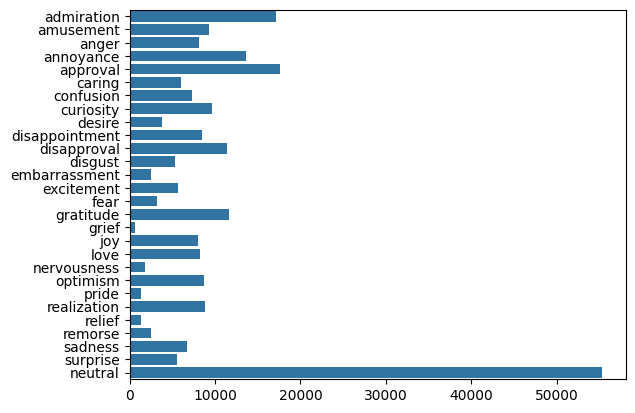

In [10]:
sns.barplot(df[emotions].sum(), orient="h")

In [11]:
text_tokens = [tokenizer.encode(text) for text in df["text"]]

Token indices sequence length is longer than the specified maximum sequence length for this model (1435 > 1024). Running this sequence through the model will result in indexing errors


In [12]:
len_tokens = [len(tokens) for tokens in text_tokens]

<Axes: ylabel='Count'>

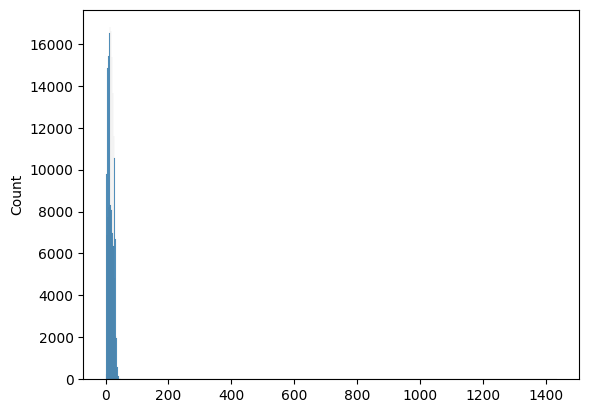

In [13]:
sns.histplot(len_tokens)

<Axes: ylabel='Count'>

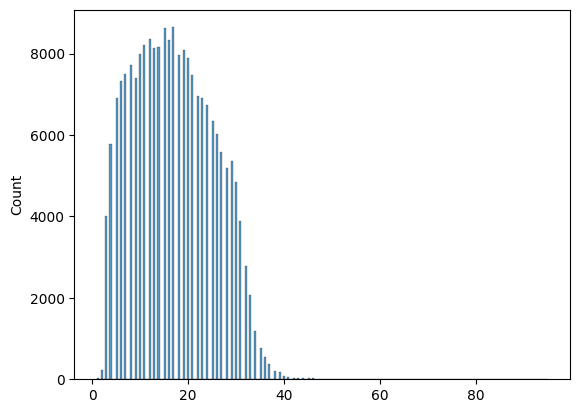

In [14]:
sns.histplot([x for x in len_tokens if x < 100])

In [15]:
np.percentile(len_tokens, 95)

np.float64(31.0)

In [16]:
text_tokens_pad = keras.utils.pad_sequences(text_tokens, maxlen=31, padding='post', truncating='post', value=tokenizer.eos_token_id)

In [17]:
labels = df[emotions].to_numpy()

In [18]:
labels

array([[0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(211225, 28), dtype=int32)

<Axes: ylabel='Count'>

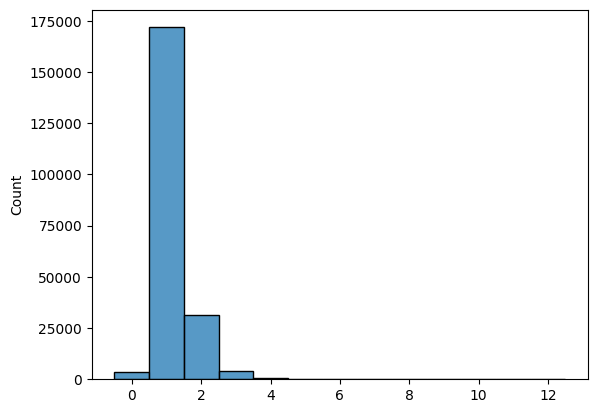

In [19]:
sns.histplot(labels.sum(axis=1), discrete=True)

In [20]:
len(df["text"].unique())

57732

In [21]:
agg_rules = {e: "max" for e in emotions}
grouped = df.groupby("id").agg({"text": "first", **agg_rules}).reset_index()

<Axes: ylabel='Count'>

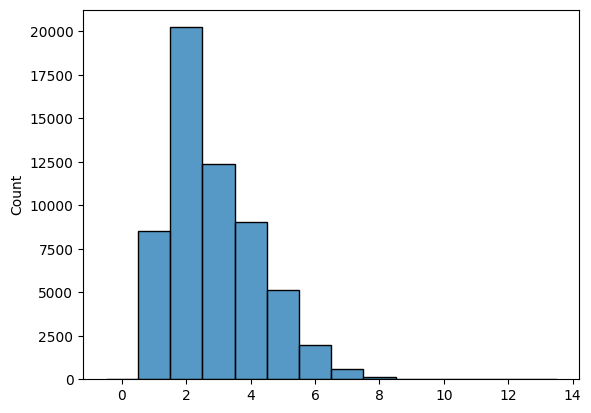

In [22]:
sns.histplot(grouped[emotions].to_numpy().sum(axis=1), discrete=True)

<Axes: >

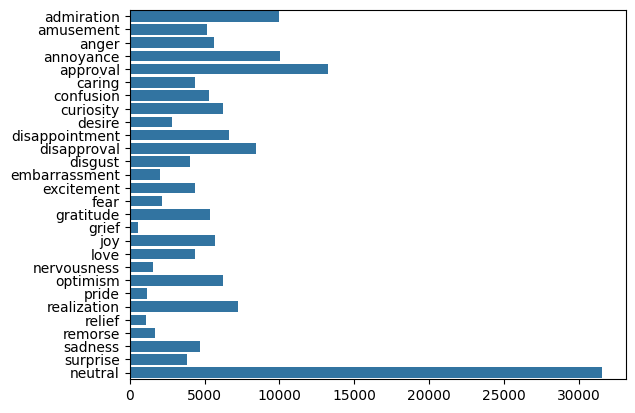

In [23]:
sns.barplot(grouped[emotions].sum(), orient="h")

In [24]:
text_tokens = [tokenizer.encode(text) for text in grouped["text"]]

In [25]:
text_tokens

[[22968,
  355,
  685,
  20608,
  60,
  481,
  3283,
  502,
  13,
  27777,
  18529,
  593,
  284,
  9436,
  2884,
  27166,
  571,
  8553,
  393,
  3154,
  2125,
  447,
  247,
  83,
  326,
  2089],
 [1639, 17948, 340, 13, 1119, 2826, 345, 588, 257, 277, 2509, 13],
 [14990,
  26,
  7707,
  1400,
  517,
  3115,
  36859,
  82,
  329,
  685,
  20608,
  4083,
  3497,
  3492,
  329,
  1194,
  5442,
  1622,
  326,
  5645,
  287,
  18641,
  13],
 [2396, 881, 640, 7448, 13, 1892, 13],
 [10161,
  6421,
  423,
  257,
  11441,
  2033,
  286,
  3626,
  1234,
  656,
  606,
  11,
  543,
  691,
  1838,
  262,
  1109,
  326,
  8168,
  3544,
  606,
  6507,
  1082],
 [5703,
  1204,
  492,
  314,
  1254,
  588,
  1312,
  1101,
  655,
  257,
  38473,
  326,
  815,
  307,
  4615,
  13],
 [9690,
  329,
  262,
  5608,
  582,
  5145,
  8192,
  257,
  1049,
  968,
  6280,
  447,
  247,
  82,
  12882],
 [9,
  9930,
  547,
  407,
  9,
  30325,
  224,
  2818,
  13,
  314,
  447,
  247,
  76,
  1654,
  484,
  547,
 

In [26]:
text_tokens = [[t + 1 for t in seq] for seq in text_tokens]

In [27]:
text_token_len = [len(seq) for seq in text_tokens]

In [28]:
np.percentile(text_token_len, 95)

np.float64(31.0)

In [29]:
text_tokens_pad = keras.utils.pad_sequences(text_tokens, maxlen=31, padding='post', truncating='post', value=0)

In [43]:
text_tokens_pad

array([[22969,   356,   686, ...,     0,     0,     0],
       [ 1640, 17949,   341, ...,     0,     0,     0],
       [14991,    27,  7708, ...,     0,     0,     0],
       ...,
       [ 4678,   306,  8104, ...,   508,    14,     0],
       [   40,   994, 12237, ...,     0,     0,     0],
       [18691,   784,   327, ...,     0,     0,     0]],
      shape=(58011, 31), dtype=int32)

In [30]:
labels = grouped[emotions].to_numpy()

In [31]:
labels

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [1, 1, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 1]], shape=(58011, 28), dtype=int32)

In [32]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    text_tokens_pad, labels, test_size=0.2, random_state=42
)

# Model

Implement your model. The model should have the RNN architecture (with LSTM or GRU cells), support stacking and bidirectional feature extraction.

In [33]:
def get_name(
    prefix: str | None = None, suffix: str | None = None, separator: str = "_"
) -> str | None:
    if prefix and suffix:
        return prefix + separator + suffix
    return prefix or suffix or None

In [34]:
def get_model(
    units: int,
    n_tokens: int,
    n_labels: int,
    n_stacks: int = 1,
    bidirectional: bool = False,
    name: str | None = None,
    cell_type: type[keras.layers.Layer] = keras.layers.LSTMCell,
    variable_seq_len: bool = False
) -> keras.Model:
    """Creates a model with RNN architecture for sequence multilabel classification.

    Arguments:
        units: dimensionality of RNN cells
        n_tokens: number of tokens in the tokenizer dictionary
        n_labels: number of labels to be predicted
        n_stacks: number of RNN cells in the stack (1 -- no stacking)
        bidirectional: whether or not the model is bidirectional
        name: the model name
        cell_type: type of a cell to use, either keras.layers.LSTMCell or keras.layers.GRUCell

    Returns:
        The model"""

    def build_rnn(x: keras.layers.Layer) -> keras.layers.Layer:
        for i in range(n_stacks):
            is_last = i == n_stacks - 1

            rnn = keras.layers.RNN(cell_type(units=units), return_sequences=not is_last)

            if bidirectional:
                x = keras.layers.Bidirectional(rnn)(x)
            else:
                x = rnn(x)

        return x

    inputs = keras.Input(shape=(31,), dtype="int32")
    x = keras.layers.Embedding(n_tokens, 64, mask_zero=variable_seq_len)(inputs)

    x = build_rnn(x)

    x = keras.layers.Dropout(0.5)(x)
    x = keras.layers.Dense(128, activation="relu")(x)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Dense(n_labels, activation="sigmoid")(x)

    return keras.models.Model(inputs=inputs, outputs=x, name=name)


In [35]:
from pathlib import Path

MODEL_CHECKPOINT_DIR = Path("../../model_checkpoints")
LOGS_DIR = Path("../../logs/rnn_sequence_classification")

# Training

Train several models on the two dataset variants. Use either of the cell types (LSTM or GRU)
* Simple RNN (no stacking, one direction)
* Stacked RNN (stacking, one direction)
* Bidirectional RNN (no stacking, bidirectional)
* Stacked Bidirectional RNN (stacking, bidirectional)

In [35]:
model_configs = [
    {
        "units": 64,
        "name": "Simple RNN",
        "bidirectional": False,
        "n_stacks": 1,
        "cell_type": keras.layers.LSTMCell,
        "variable_len": False,
    },
    {
        "units": 64,
        "name": "Stacked RNN",
        "bidirectional": False,
        "n_stacks": 3,
        "cell_type": keras.layers.LSTMCell,
        "variable_len": False,
    },
    {
        "units": 64,
        "name": "Bidirectional RNN",
        "bidirectional": True,
        "n_stacks": 1,
        "cell_type": keras.layers.LSTMCell,
        "variable_len": False,
    },
    {
        "units": 64,
        "name": "Stacked Bidirectional RNN",
        "bidirectional": True,
        "n_stacks": 3,
        "cell_type": keras.layers.LSTMCell,
        "variable_len": False,
    },
    {
        "units": 64,
        "name": "Simple RNN variable_seq_len",
        "bidirectional": False,
        "n_stacks": 1,
        "cell_type": keras.layers.LSTMCell,
        "variable_len": True,
    },
    {
        "units": 64,
        "name": "Stacked RNN variable_seq_len",
        "bidirectional": False,
        "n_stacks": 3,
        "cell_type": keras.layers.LSTMCell,
        "variable_len": True,
    },
    {
        "units": 64,
        "name": "Bidirectional RNN variable_seq_len",
        "bidirectional": True,
        "n_stacks": 1,
        "cell_type": keras.layers.LSTMCell,
        "variable_len": True,
    },
    {
        "units": 64,
        "name": "Stacked Bidirectional RNN variable_seq_len",
        "bidirectional": True,
        "n_stacks": 3,
        "cell_type": keras.layers.LSTMCell,
        "variable_len": True,
    },
]

In [36]:
models = [
    get_model(
        units=config["units"],
        n_tokens=len(tokenizer.get_vocab()) + 1,
        n_labels=len(emotions),
        name=config["name"],
        bidirectional=config["bidirectional"],
        n_stacks=config["n_stacks"],
        cell_type=config["cell_type"],
        variable_seq_len=config["variable_len"],
    )
    for config in model_configs
]

Which loss should be used to multilabel classification? Which metrics?

In [37]:
for model in models:
    model.compile(
        loss=keras.losses.BinaryFocalCrossentropy(
            alpha=0.25,
            gamma=2.0,
        ),
        optimizer=keras.optimizers.AdamW(1e-3),
        metrics=[
            keras.metrics.AUC(name="auc", multi_label=True),
            keras.metrics.F1Score(name="f1_macro", average="macro", threshold=0.5),
            keras.metrics.F1Score(name="f1_micro", average="micro", threshold=0.5),
        ],
    )

In [194]:
import gc


class Stabilizer(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

In [195]:
from torch.utils.tensorboard import SummaryWriter


class PyTorchTensorBoard(keras.callbacks.Callback):
    def __init__(self, log_dir):
        super().__init__()
        self.writer = SummaryWriter(log_dir)

    def on_epoch_end(self, epoch, logs=None):
        if logs:
            for key, value in logs.items():
                self.writer.add_scalar(key, value, epoch)

In [196]:
from datetime import UTC, datetime


def get_callbacks(model_name: str) -> list[keras.callbacks.Callback]:
    return [
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            MODEL_CHECKPOINT_DIR / f"{model_name}_auc.keras",
            monitor="val_auc",
            mode="max",
            save_best_only=True,
        ),
        keras.callbacks.ModelCheckpoint(
            MODEL_CHECKPOINT_DIR / f"{model_name}_f1_macro.keras",
            monitor="val_f1_macro",
            mode="max",
            save_best_only=True,
        ),
        Stabilizer(),
        PyTorchTensorBoard(
            LOGS_DIR / f"{model_name}-{datetime.now(tz=UTC).strftime('%Y%m%d-%H%M%S')}"
        ),
    ]

In [ ]:
for model in models:
    model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        callbacks=get_callbacks(model.name),
        batch_size=128,
    )

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 49s 134ms/step - auc: 0.5165 - f1_macro: 0.0338 - f1_micro: 0.2148 - loss: 0.0843 - val_auc: 0.5900 - val_f1_macro: 0.0252 - val_f1_micro: 0.2847 - val_loss: 0.0771 - learning_rate: 0.0010
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 50s 138ms/step - auc: 0.6278 - f1_macro: 0.0320 - f1_micro: 0.2491 - loss: 0.0756 - val_auc: 0.7085 - val_f1_macro: 0.0625 - val_f1_micro: 0.2815 - val_loss: 0.0702 - learning_rate: 0.0010
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 51s 141ms/step - auc: 0.7418 - f1_macro: 0.0810 - f1_micro: 0.2933 - loss: 0.0684 - val_auc: 0.7529 - val_f1_macro: 0.1023 - val_f1_micro: 0.3132 - val_loss: 0.0669 - learning_rate: 0.0010
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 49s 136ms/step - auc: 0.7883 - f1_macro: 0.1110 - f1_micro: 0.3187 - loss: 0.0645 - val_auc: 0.7617 - val_f1_macro: 0.1318 - val_f1_micro: 0.3449 - val_loss: 0.0665 - learning_rate: 0.0010
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 50s 136ms/step - auc: 0.8138 - f1_macro: 0.1

# Evaluation

Evaluate the models you trained on the test datasets. Plot ROC curves for each label (use `sklearn.metrics.RocCurveDisplay`) for each model.

In [36]:
def plot_roc_curve(
    X: np.ndarray, y: np.ndarray, model: keras.Model, ax: plt.Axes | None = None
) -> float:
    """Plots ROC curves for each of the labels (on a single axes) and outputs mean ROC AUC score.

    Arguments:
        X: model inputs
        y: ground thruths
        model: model to plot the curve for
        ax: axes to plot on

    Returns:
        Mean ROC AUC score"""

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))

    y_pred = model.predict(X, verbose=0)

    aucs: list[float] = []
    for i, emotion in enumerate(emotions):
        display = sklearn.metrics.RocCurveDisplay.from_predictions(
            y[:, i],
            y_pred[:, i],
            ax=ax,
            name=emotion,
        )
        aucs.append(display.roc_auc)

    mean_auc = float(np.mean(aucs))

    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="chance")

    ax.set_title(f"{model.name}: ROC per emotion for model (mean AUC = {mean_auc:.4f})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize="small", ncol=2)

    return mean_auc

In [203]:
models_roc = []
models_f1 = []

for file in MODEL_CHECKPOINT_DIR.iterdir():
    if file.is_dir():
        continue

    model = keras.models.load_model(file)

    if "auc" in file.name:
        models_roc.append(model)
    else:
        models_f1.append(model)

Plot the mean ROC AUC scores. Which model has the highest score? On what kind of dataset?

Mean ROC AUC: 0.7988


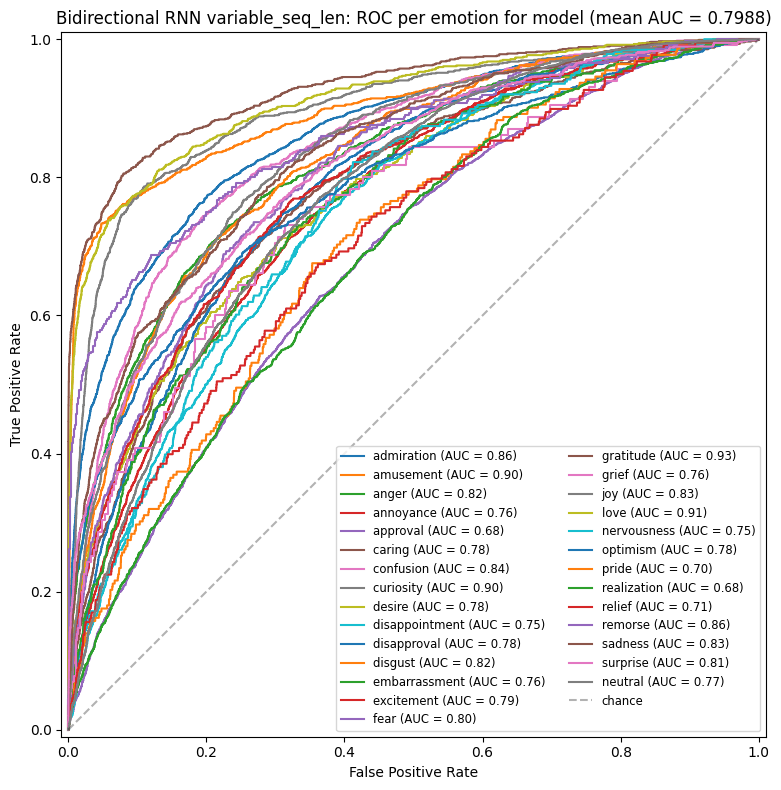

Mean ROC AUC: 0.8005


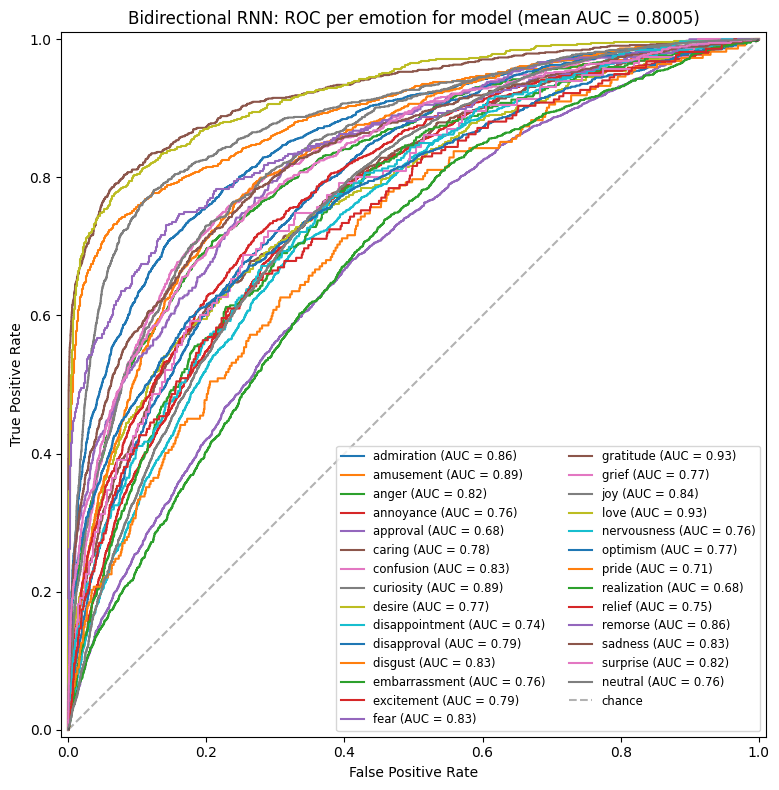

Mean ROC AUC: 0.7882


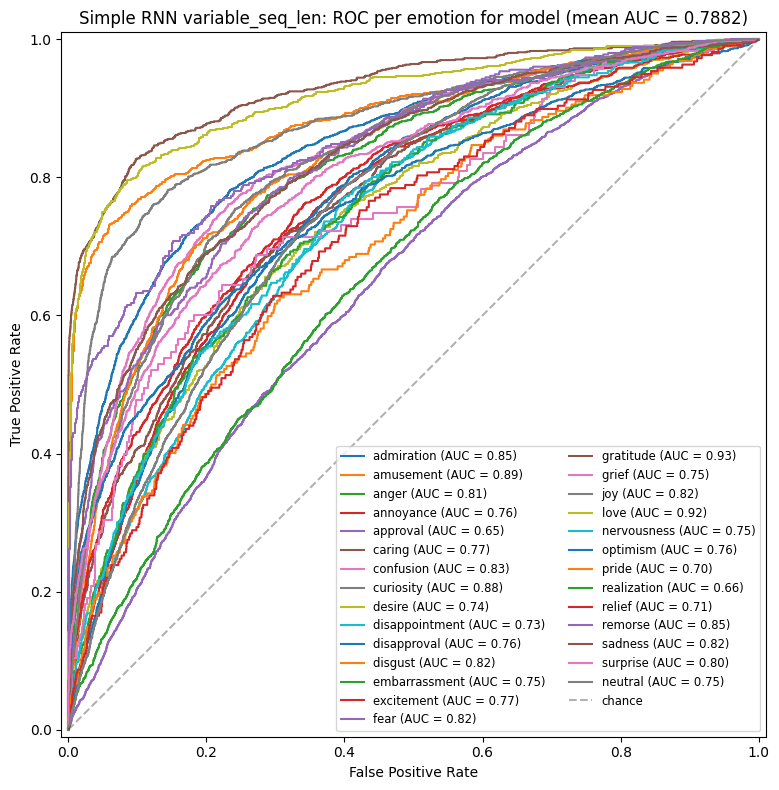

Mean ROC AUC: 0.7735


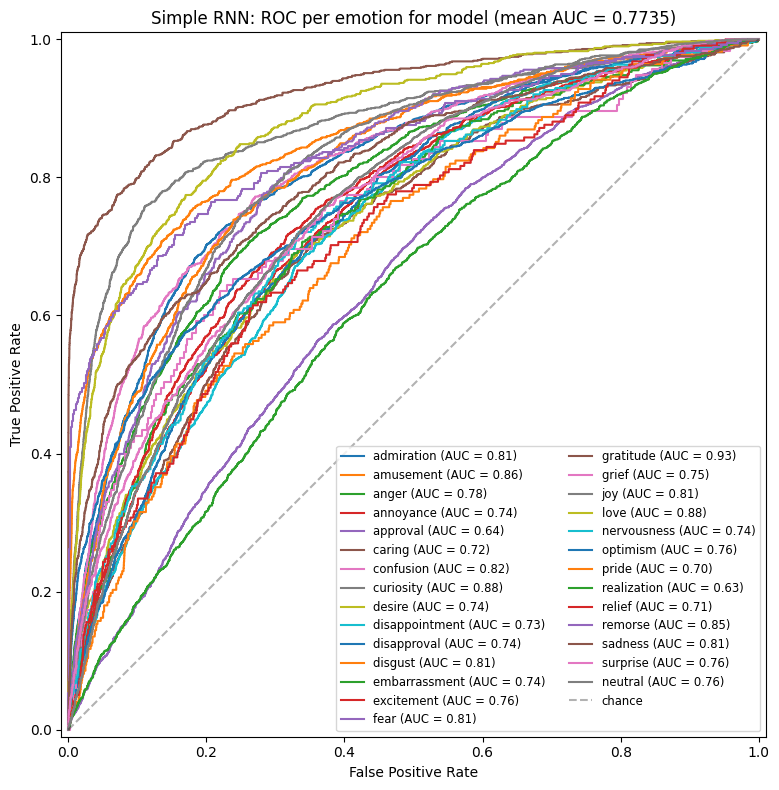

Mean ROC AUC: 0.7951


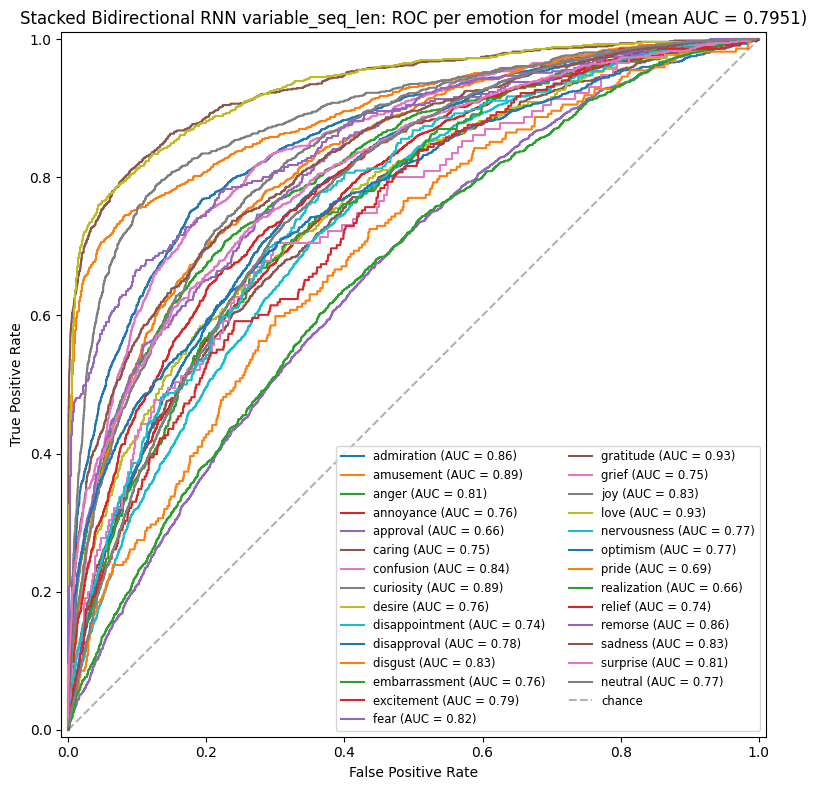

Mean ROC AUC: 0.7991


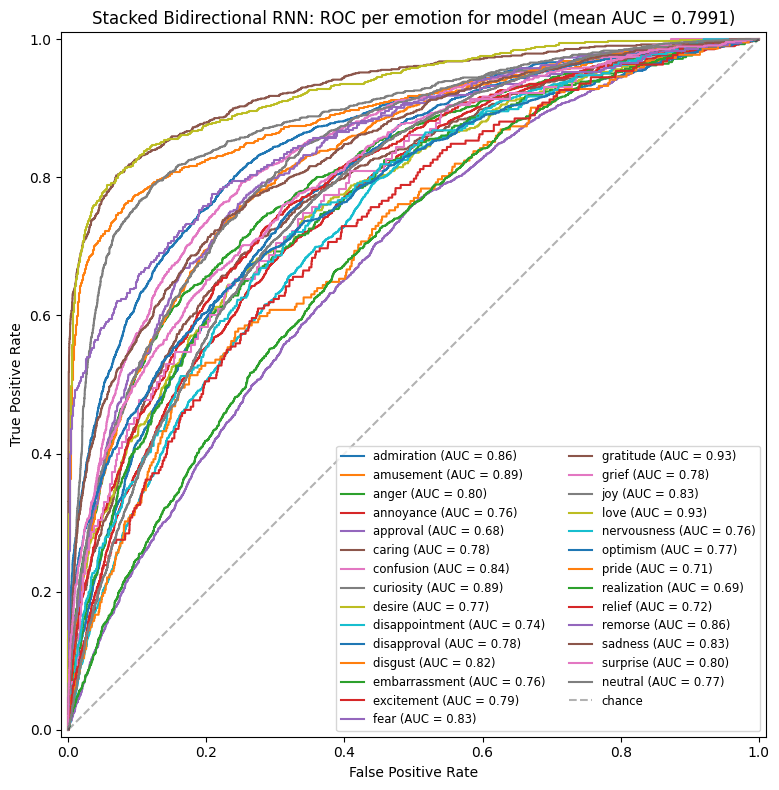

Mean ROC AUC: 0.7730


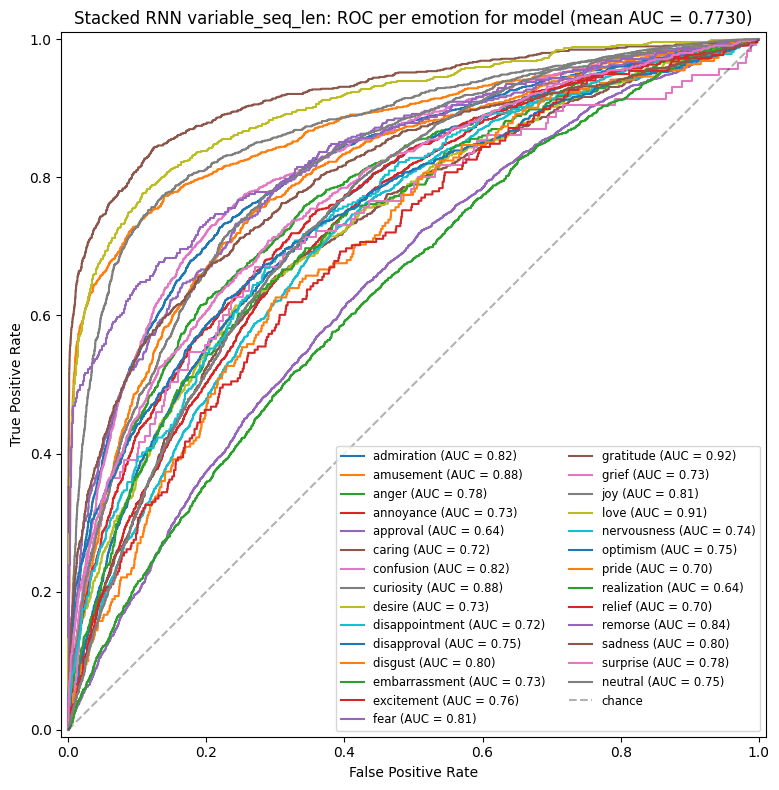

Mean ROC AUC: 0.7793


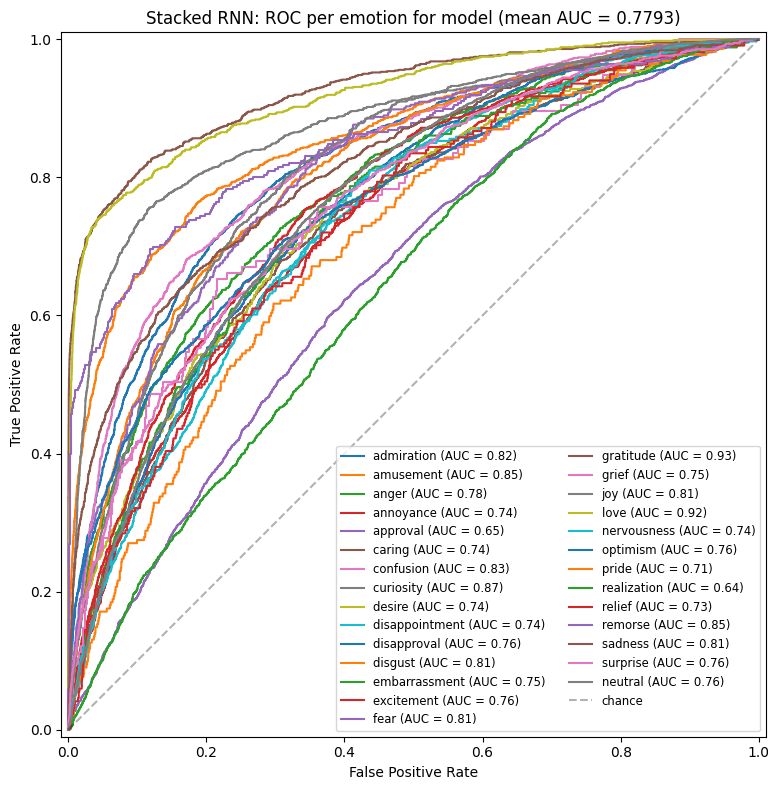

In [204]:
for model in models_roc:
    fig, ax = plt.subplots(figsize=(10, 8))
    mean_auc = plot_roc_curve(X_test, y_test, model, ax=ax)
    print(f"Mean ROC AUC: {mean_auc:.4f}")
    plt.tight_layout()
    plt.show()

Inspect the best model performance closer. Come up with some sentences (in English). Does the model output sensible results?

In [82]:
def tokenize_text(text: str, max_length: int | None = None) -> np.ndarray:
    tokens = tokenizer.encode(text)
    tokens = [t + 1 for t in tokens]
    tokens = keras.utils.pad_sequences(
        [tokens], maxlen=max_length, padding="post", truncating="post", value=0
    )
    return tokens

In [83]:
def label_text(
    text: str, model: keras.Model, threshold: float = 0.5, max_length: int | None = None
) -> list[str]:
    """Computes the model output for `text` and outputs a list of emotions that have a probability of at least `threshold`

    Arguments:
        text: text to label
        model: model to use
        threshold: threshold to use
        max_length: max length for tokenization

    Return:
        List of predicted emotion labels"""

    tokens = tokenize_text(text, max_length)

    prediction = model.predict(tokens, verbose=0)

    output = []

    for probs in prediction:
        for prob, emotion in zip(probs, emotions):
            if prob > threshold:
                output.append(emotion)

    return output

In [122]:
import textwrap

In [176]:
def plot_emotion_scores(
    text: str,
    model: keras.Model,
    max_length: int | None = None,
    ax: plt.Axes | None = None,
):
    """Plots a bar plot of emotion probabilities for given `text` using `model`.

    Arguments:
        text: text to label
        model: model to use
        max_length: max length for tokenization
        ax: axes to plot on"""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    tokens = tokenize_text(text, max_length)

    prediction = model.predict(tokens, verbose=0)

    sns.barplot(x=prediction[0], y=emotions, ax=ax, orient="h")
    plt.title(f"{model.name}: Emotions probabilities")

    text = "\n".join(textwrap.wrap(text, 20))
    ax.text(
        0.98,
        0.98,
        text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        family='monospace',
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.5},
    )
    ax.set_xlim(left=None, right=max(prediction[0]) * 1.4)

For each of your texts get a list of emotion labels and plot emotion scores

In [187]:
texts = ["I like pizza", "I dont like pizza", "I hate pizza", "I don't dislike pizza"]

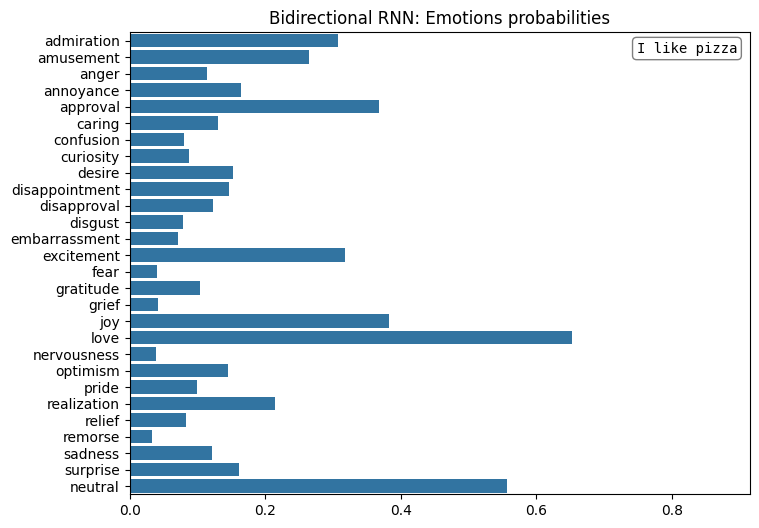

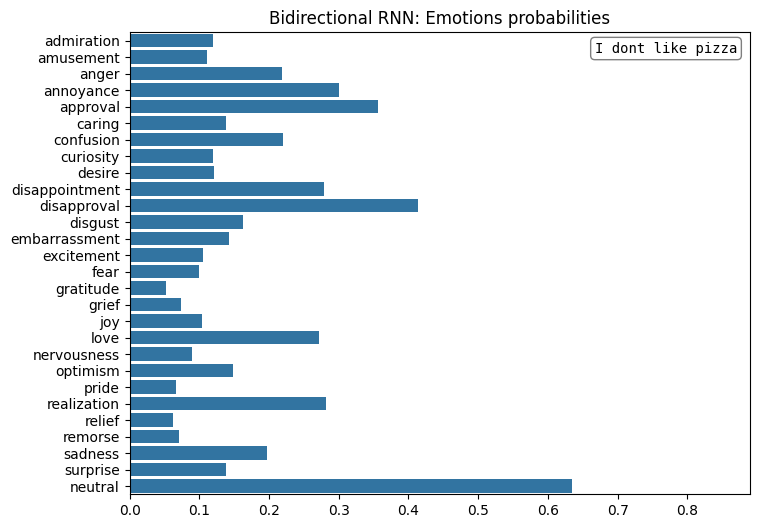

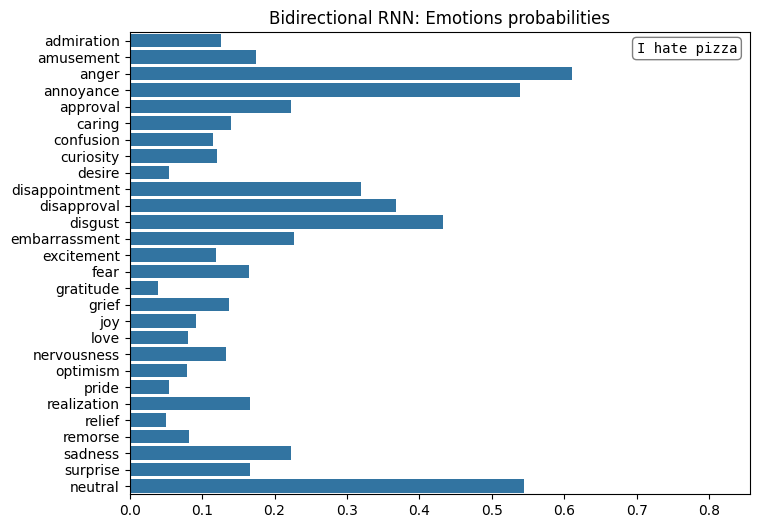

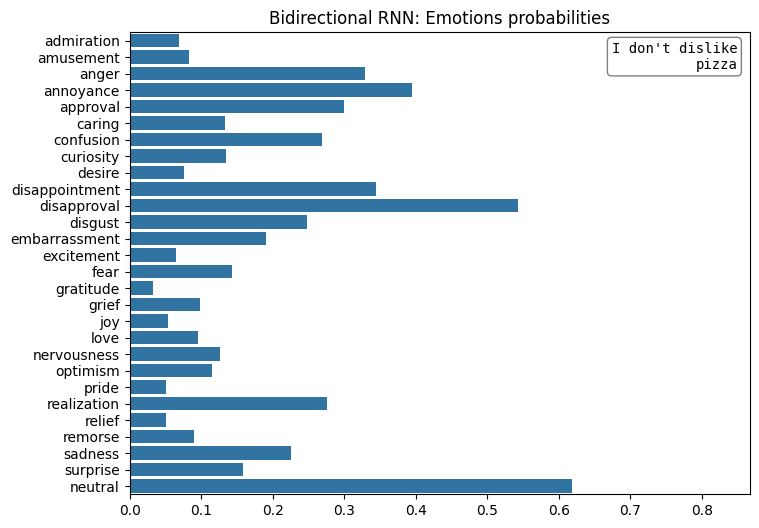

In [188]:
for text in texts:
    plot_emotion_scores(text, models_roc[1], 31)

# Bonus

Train and evaluate the same model as your best one, but use a different cell type

In [205]:
bonus_model_config = {
    "units": 64,
    "name": "Bidirectional RNN GRU",
    "bidirectional": True,
    "n_stacks": 1,
    "cell_type": keras.layers.GRUCell,
    "variable_len": False,
}

In [206]:
bonus_model = get_model(
    units=bonus_model_config["units"],
    n_tokens=len(tokenizer.get_vocab()) + 1,
    n_labels=len(emotions),
    name=bonus_model_config["name"],
    bidirectional=bonus_model_config["bidirectional"],
    n_stacks=bonus_model_config["n_stacks"],
    cell_type=bonus_model_config["cell_type"],
    variable_seq_len=bonus_model_config["variable_len"],
)

In [207]:
bonus_model.compile(
    loss=keras.losses.BinaryFocalCrossentropy(
        alpha=0.25,
        gamma=2.0,
    ),
    optimizer=keras.optimizers.AdamW(1e-3),
    metrics=[
        keras.metrics.AUC(name="auc", multi_label=True),
        keras.metrics.F1Score(name="f1_macro", average="macro", threshold=0.5),
        keras.metrics.F1Score(name="f1_micro", average="micro", threshold=0.5),
    ],
)

In [208]:
bonus_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    callbacks=get_callbacks(bonus_model.name),
    batch_size=128,
)

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 100s 277ms/step - auc: 0.5713 - f1_macro: 0.0489 - f1_micro: 0.2314 - loss: 0.0820 - val_auc: 0.7048 - val_f1_macro: 0.0722 - val_f1_micro: 0.3098 - val_loss: 0.0702 - learning_rate: 0.0010
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 98s 270ms/step - auc: 0.7313 - f1_macro: 0.1135 - f1_micro: 0.3191 - loss: 0.0686 - val_auc: 0.7721 - val_f1_macro: 0.1663 - val_f1_micro: 0.3699 - val_loss: 0.0647 - learning_rate: 0.0010
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 98s 271ms/step - auc: 0.8034 - f1_macro: 0.1947 - f1_micro: 0.3844 - loss: 0.0621 - val_auc: 0.7944 - val_f1_macro: 0.2400 - val_f1_micro: 0.4213 - val_loss: 0.0621 - learning_rate: 0.0010
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 99s 272ms/step - auc: 0.8382 - f1_macro: 0.2412 - f1_micro: 0.4239 - loss: 0.0582 - val_auc: 0.8009 - val_f1_macro: 0.2640 - val_f1_micro: 0.4429 - val_loss: 0.0622 - learning_rate: 0.0010
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 136s 376ms/step - auc: 0.8599 - f1_macro: 0